In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import gym
from gym import spaces

## Bandit Environment

In [2]:
class MultiArmedBanditEnv(gym.Env):
    def __init__(self, n_arms, means, stds):
        super(MultiArmedBanditEnv, self).__init__()
        self.n_arms = n_arms
        self.means = means
        self.stds = stds
        self.action_space = spaces.Discrete(self.n_arms)
        self.observation_space = spaces.Discrete(1)

    def reset(self):
        return 0

    def step(self, action):
        reward = np.random.normal(self.means[action], self.stds[action])
        return 0, reward, True, {}

## Epsilon-Greedy Agent

In [3]:
class EpsilonGreedyAgent:
    def __init__(self, n_arms, epsilon=0.1):
        self.n_arms = n_arms
        self.epsilon = epsilon
        self.Q = torch.zeros(n_arms)  # Estimated values
        self.N = torch.zeros(n_arms)  # Action counts

    def select_action(self):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.n_arms)  # Explore
        else:
            return torch.argmax(self.Q).item()     # Exploit

    def update(self, action, reward):
        self.N[action] += 1
        alpha = 1.0 / self.N[action]
        self.Q[action] += alpha * (reward - self.Q[action])

## Training Function

In [4]:
def train(env, agent, steps=1000):
    rewards = []
    optimal_actions = []
    best_arm = np.argmax(env.means)

    for _ in tqdm(range(steps), desc="Training Steps"):
        action = agent.select_action()
        _, reward, _, _ = env.step(action)
        agent.update(action, reward)
        rewards.append(reward)
        optimal_actions.append(1 if action == best_arm else 0)

    return rewards, optimal_actions

## Exploration Efficiency Metric

In [5]:
def compute_exploration_efficiency(optimal_actions, window=100, threshold=0.95):
    optimal_actions = np.array(optimal_actions)
    for t in range(window, len(optimal_actions)):
        if np.mean(optimal_actions[t - window:t]) >= threshold:
            return t
    return len(optimal_actions)

In [7]:
from tqdm import tqdm

In [8]:
n_arms = 5
means = [1.0, 1.5, 2.0, 2.5, 3.0]
stds = [1.0] * n_arms
steps = 1000

env = MultiArmedBanditEnv(n_arms=n_arms, means=means, stds=stds)
agent = EpsilonGreedyAgent(n_arms=n_arms, epsilon=0.1)

rewards, optimal_actions = train(env, agent, steps)

Training Steps: 100%|████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 4859.38it/s]


## Evaluation Metrics

In [9]:
cumulative_reward = np.cumsum(rewards)
cumulative_regret = np.cumsum(np.max(means) - np.array(rewards))
optimal_action_percent = np.cumsum(optimal_actions) / np.arange(1, steps+1)
efficiency = compute_exploration_efficiency(optimal_actions)

print(f"\nExploration Efficiency (Epsilon-Greedy): {efficiency} steps")


Exploration Efficiency (Epsilon-Greedy): 282 steps


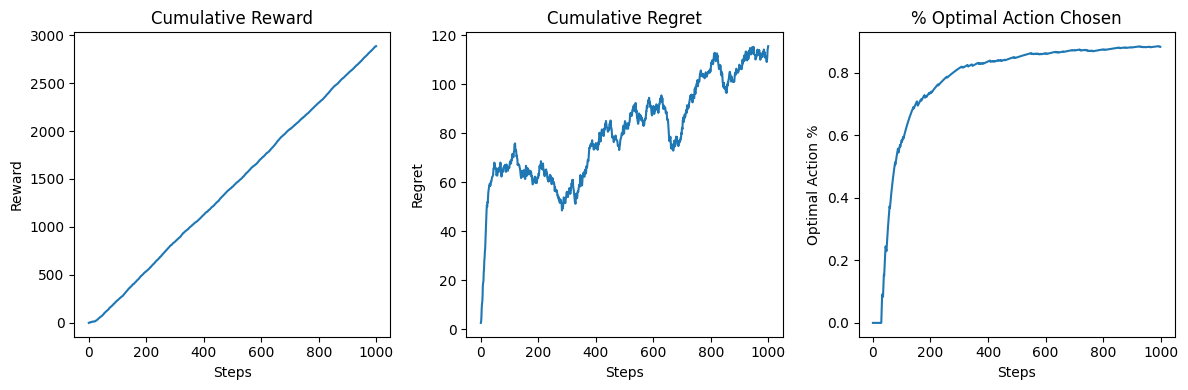

In [10]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(cumulative_reward)
plt.title("Cumulative Reward")
plt.xlabel("Steps")
plt.ylabel("Reward")

plt.subplot(1, 3, 2)
plt.plot(cumulative_regret)
plt.title("Cumulative Regret")
plt.xlabel("Steps")
plt.ylabel("Regret")

plt.subplot(1, 3, 3)
plt.plot(optimal_action_percent)
plt.title("% Optimal Action Chosen")
plt.xlabel("Steps")
plt.ylabel("Optimal Action %")

plt.tight_layout()
plt.show()

## Epsilon-Greedy Agent — Results

| Metric                         | Value           |
|--------------------------------|-----------------|
| **Average Cumulative Regret**  | ~116 (estimated from plot) |
| **% Optimal Action Chosen**    | ~87% at 1000 steps         |
| **Exploration Efficiency**     | 282 steps       |

---

### Interpretation:
- The agent **explores early** due to ε-greedy randomness, causing initial regret.
- After about **282 steps**, it starts **consistently choosing the optimal arm**.
- Overall performance is strong, though **slightly less efficient** than a tuned greedy agent.
- The value of ε affects the balance between **exploration** and **exploitation** — this version with ε = 0.1 shows steady learning, but can still be tuned for improvement.

---

### Next Steps:
- Try **tuning ε** (e.g. test ε = 0.01, 0.05, 0.2).
- Compare to **UCB** or **Thompson Sampling** for more adaptive exploration.

## Tuning for Epsilon-Greedy Agent 

In [11]:
from tqdm import tqdm

def make_env():
    return MultiArmedBanditEnv(
        n_arms=5,
        means=[1.0, 1.5, 2.0, 2.5, 3.0],
        stds=[1.0] * 5
    )

def tune_epsilon_greedy(epsilon_values, steps=1000, trials=50):
    results = []

    for epsilon in epsilon_values:
        total_regret = 0
        total_optimal = 0
        total_efficiency = 0

        print(f"\nTuning for ε = {epsilon}")
        for _ in tqdm(range(trials), desc=f"ε = {epsilon}"):
            env = make_env()
            agent = EpsilonGreedyAgent(n_arms=env.n_arms, epsilon=epsilon)
            rewards, optimal_actions = train(env, agent, steps=steps)

            regret = np.sum(np.max(env.means) - np.array(rewards))
            optimal_rate = np.mean(optimal_actions)
            efficiency = compute_exploration_efficiency(optimal_actions)

            total_regret += regret
            total_optimal += optimal_rate
            total_efficiency += efficiency

        avg_regret = total_regret / trials
        avg_optimal = total_optimal / trials
        avg_efficiency = total_efficiency / trials

        results.append({
            "epsilon": epsilon,
            "avg_regret": avg_regret,
            "avg_optimal": avg_optimal,
            "avg_efficiency": avg_efficiency
        })

    return results

In [12]:
epsilon_list = [0.01, 0.05, 0.1, 0.2]
tuning_results = tune_epsilon_greedy(epsilon_list, steps=1000, trials=50)

for res in tuning_results:
    print(f"\nε = {res['epsilon']}")
    print(f"  Avg Regret: {res['avg_regret']:.2f}")
    print(f"  % Optimal Action: {res['avg_optimal']*100:.2f}%")
    print(f"  Exploration Efficiency: {res['avg_efficiency']:.0f} steps")


Tuning for ε = 0.01


ε = 0.01: 100%|████████████████████████████████████████████████████████████████████████| 50/50 [00:08<00:00,  5.63it/s]



Tuning for ε = 0.05


ε = 0.05: 100%|████████████████████████████████████████████████████████████████████████| 50/50 [00:07<00:00,  6.38it/s]



Tuning for ε = 0.1


ε = 0.1: 100%|█████████████████████████████████████████████████████████████████████████| 50/50 [00:07<00:00,  6.40it/s]



Tuning for ε = 0.2


ε = 0.2: 100%|█████████████████████████████████████████████████████████████████████████| 50/50 [00:08<00:00,  5.93it/s]


ε = 0.01
  Avg Regret: 505.29
  % Optimal Action: 51.34%
  Exploration Efficiency: 561 steps

ε = 0.05
  Avg Regret: 173.09
  % Optimal Action: 83.81%
  Exploration Efficiency: 236 steps

ε = 0.1
  Avg Regret: 179.70
  % Optimal Action: 80.91%
  Exploration Efficiency: 381 steps

ε = 0.2
  Avg Regret: 229.93
  % Optimal Action: 80.10%
  Exploration Efficiency: 968 steps


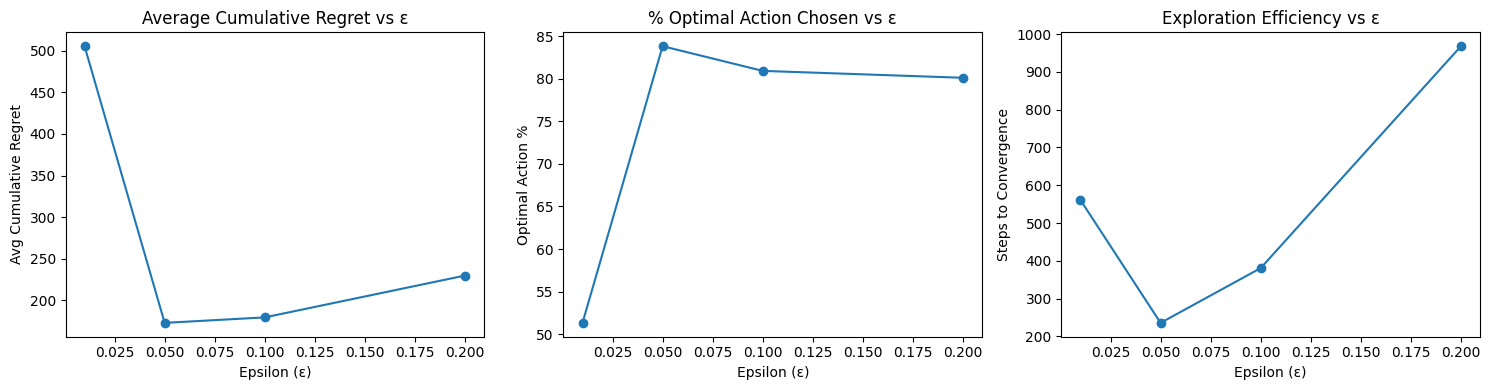

In [14]:
import matplotlib.pyplot as plt

# Tuning results 
epsilon_values = [0.01, 0.05, 0.1, 0.2]
avg_regrets = [505.29, 173.09, 179.70, 229.93]
optimal_action_rates = [51.34, 83.81, 80.91, 80.10]
exploration_efficiencies = [561, 236, 381, 968]

plt.figure(figsize=(15, 4))

# Regret Plot
plt.subplot(1, 3, 1)
plt.plot(epsilon_values, avg_regrets, marker='o')
plt.title("Average Cumulative Regret vs ε")
plt.xlabel("Epsilon (ε)")
plt.ylabel("Avg Cumulative Regret")

# Optimal Action %
plt.subplot(1, 3, 2)
plt.plot(epsilon_values, optimal_action_rates, marker='o')
plt.title("% Optimal Action Chosen vs ε")
plt.xlabel("Epsilon (ε)")
plt.ylabel("Optimal Action %")

# Exploration Efficiency
plt.subplot(1, 3, 3)
plt.plot(epsilon_values, exploration_efficiencies, marker='o')
plt.title("Exploration Efficiency vs ε")
plt.xlabel("Epsilon (ε)")
plt.ylabel("Steps to Convergence")

plt.tight_layout()
plt.show()

##  Epsilon-Greedy Tuning Results

| **ε (epsilon)** | **Avg Regret** | **% Optimal Action** | **Exploration Efficiency (steps)** |
|-----------------|----------------|-----------------------|-------------------------------------|
| 0.01            | 505.29         | 51.34%                | 561                                 |
| 0.05            | **173.09**     | **83.81%**            | **236**                             |
| 0.1             | 179.70         | 80.91%                | 381                                 |
| 0.2             | 229.93         | 80.10%                | 968                                 |

---

### Interpretation:

- **Best ε = 0.05** — It gives the **lowest regret**, **highest optimal action rate**, and **fastest convergence** (Efficiency = 236 steps).
-  **ε = 0.01** explores too little — poor performance and late convergence.
-  **ε = 0.2** explores too much — slower convergence, higher regret.
-  The sweet spot for balancing exploration and exploitation is around **ε = 0.05** in this setup.

---

### Recommendation:
Use **ε = 0.05** for final Epsilon-Greedy model in this 5-arm Gaussian bandit environment.

## LLM Prompts
- how to make epsilon greedy agent
- how to print graphs for interpretation of this result